In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,roc_curve

In [5]:
df=pd.read_csv('/hospital_readmissions_30k.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/hospital_readmissions_30k.csv'

In [75]:
df=df.drop(columns=['patient_id'])

In [76]:
df[['systolic_bp','diastolic_bp']]=df['blood_pressure'].str.split('/',expand=True).astype(int)
df=df.drop(columns=['blood_pressure'])

In [77]:
df['readmitted_30_days']=(df['readmitted_30_days']=='Yes').astype(int)

categorical_cols=['gender','diabetes','hypertension','discharge_destination']
df_encoded=pd.get_dummies(df,columns=categorical_cols,drop_first=True)

In [78]:
X=df_encoded.drop(columns=['readmitted_30_days'])
y=df_encoded['readmitted_30_days']

In [79]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [80]:
model=LogisticRegression()
model.fit(X_train_scaled,y_train)

y_pred_proba=model.predict_proba(X_test_scaled)[:,1]
auc_score=roc_auc_score(y_test,y_pred_proba)
print(f"ROC-AAUC Score: {auc_score:.4f}")

ROC-AAUC Score: 0.5806


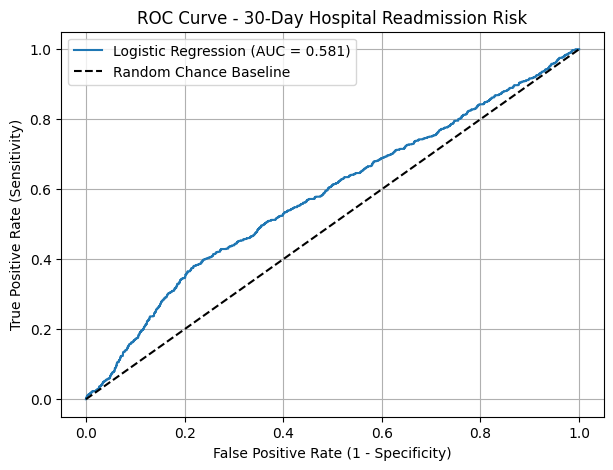

In [81]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance Baseline')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - 30-Day Hospital Readmission Risk')
plt.legend()
plt.grid(True)
plt.show()